In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import time
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error, r2_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_california_housing, load_iris
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# **Problem 1**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,499 (29.30 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,000 (19.54 KB)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9737 - loss: 0.1176
Test accuracy: 0.9737


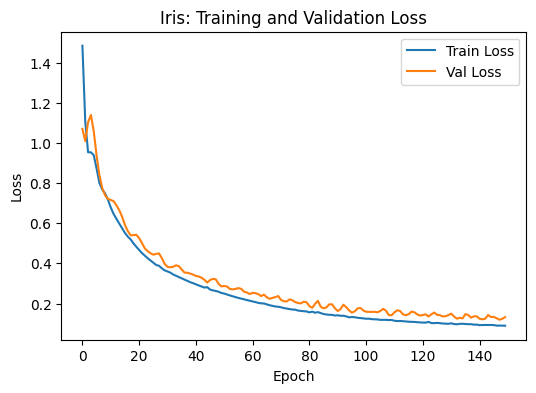

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Loading Iris data
iris = load_iris()
X, y = iris.data, iris.target

y_cat = to_categorical(y, num_classes=3)
# Split the data into 75% train and 25% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.25, random_state=42, stratify=y
)
# Architecture - 2 hidden layers (64,32,3)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
# Compile - Optimizer: Adam, Loss: Categorical cross‑entropy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train - Epochs: 150
history = model.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=1)

# Print model summary and accuracy on the test set
model.summary()
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training and validation loss curves across epochs
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Iris: Training and Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()


# **Problem 2**

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5118 - loss: 0.6927 - val_accuracy: 0.5188 - val_loss: 0.6923
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5332 - loss: 0.6913 - val_accuracy: 0.5174 - val_loss: 0.6918
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5458 - loss: 0.6900 - val_accuracy: 0.5412 - val_loss: 0.6903
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5622 - loss: 0.6885 - val_accuracy: 0.5412 - val_loss: 0.6898
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5787 - loss: 0.6864 - val_accuracy: 0.5510 - val_loss: 0.6885
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5903 - loss: 0.6835 - val_accuracy: 0.5744 - val_loss: 0.6856
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6163 - loss: 0.6794 - val_accuracy: 0.5908 - val_loss: 0.6826
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6351 - loss: 0.6733 - val_accuracy: 0.6082 - val

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 200, 50)          │       400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 10000)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 24)               │       240,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 1)                │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,051 (2.44 MB)

 Trainable params: 640,049 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Test Accuracy: 0.7450


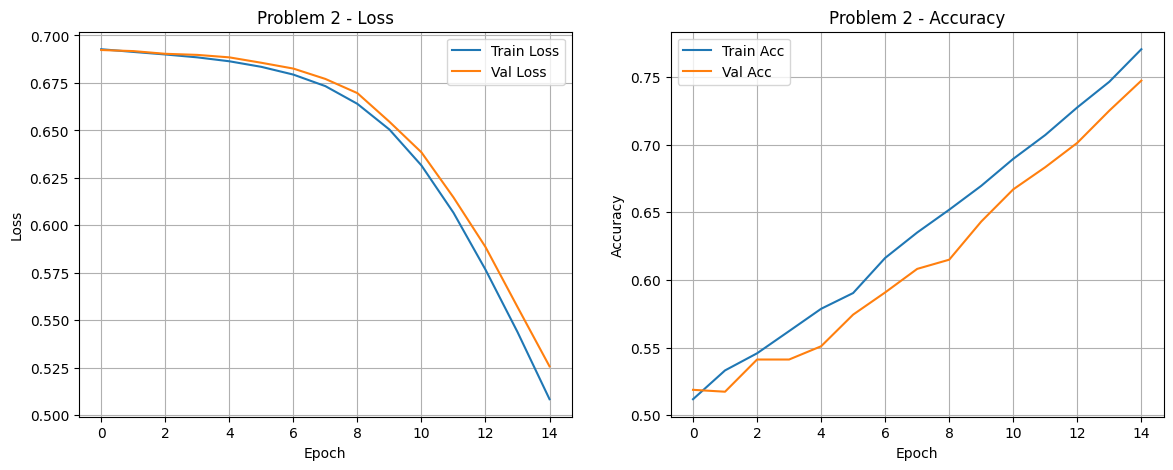

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


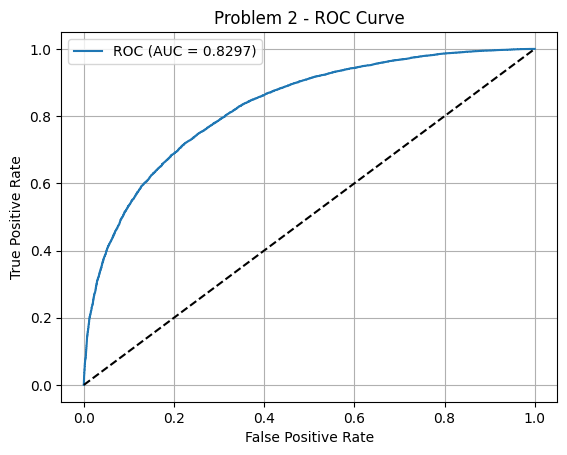

AUC: 0.8297


In [10]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import roc_curve, auc

# top 8,000 most frequent words
most_frequent = 8000
maxlen = 200
(X_train_full, y_train_full), (X_test, y_test) = imdb.load_data(num_words=most_frequent)

X_train_full = pad_sequences(X_train_full, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

#original training set and splitting it into 80 % training and 20 % validation.
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

#8,000 input dim, 50 output dim, 24 relu, 1 sigmoid output laye
model2 = keras.Sequential([
    layers.Embedding(most_frequent, 50, input_length=maxlen),
    layers.Flatten(),
    layers.Dense(24, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

#Loss: Binary cross‑entropy, Optimizer: SGD, Epochs: 15
model2.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=1)

#Print the summary of network.
model2.summary()

#Reporting the test accuracy
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc2:.4f}")

# Plotting training and validation loss and accuracy curves.
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Problem 2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.title('Problem 2 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#Drawing ROC + AUC
y_pred_prob = model2.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Problem 2 - ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

# **Problem 3**

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4999 - loss: 0.6933 - val_accuracy: 0.5066 - val_loss: 0.6930
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5132 - loss: 0.6929 - val_accuracy: 0.5030 - val_loss: 0.6931
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5143 - loss: 0.6928 - val_accuracy: 0.4996 - val_loss: 0.6935
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5200 - loss: 0.6924 - val_accuracy: 0.5074 - val_loss: 0.6929
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5237 - loss: 0.6917 - val_accuracy: 0.5194 - val_loss: 0.6924
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5355 - loss: 0.6913 - val_accuracy: 0.5150 - val_loss: 0.6928
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5402 - loss: 0.6905 - val_accuracy: 0.5238 - val_loss: 0.6917
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5582 - loss: 0.6886 - val_accuracy: 0.53

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (32, 200, 64)          │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (32, 12800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (32, 48)               │       614,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 48)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (32, 24)               │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 24)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (32, 12)               │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (32, 1)                │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,939 (4.30 MB)

 Trainable params: 1,127,937 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Deeper Model Test Accuracy: 0.6987

=== Shallow vs Deeper Comparison ===
Shallow Test Acc : 0.7450
Deeper Test Acc  : 0.6987
Shallow Overfitting gap: 0.0232
Deeper Overfitting gap : 0.0504
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


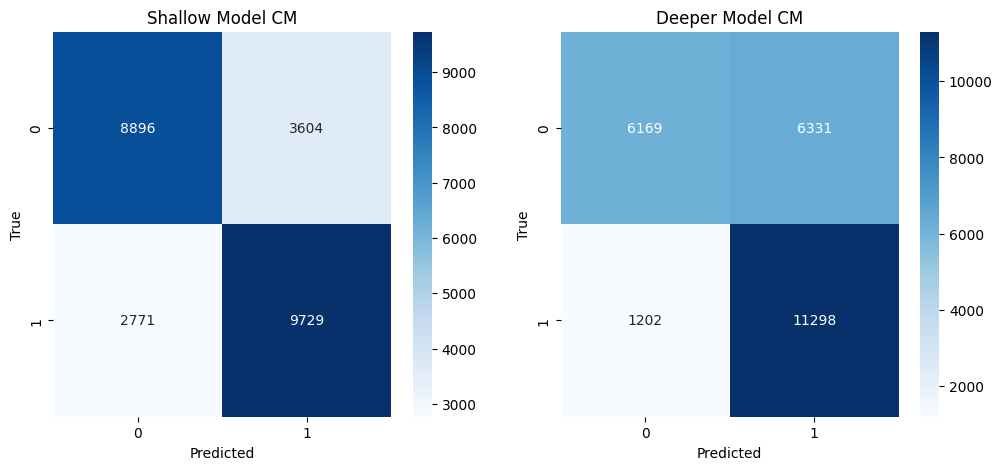


Conclusion: Deeper model usually has higher accuracy but takes more time and can overfit more. With dropout it performs better overall.


In [15]:
most_frequent = 8000
maxlen = 200
model3 = keras.Sequential([
    layers.Embedding(most_frequent, 64, input_length=maxlen),
    layers.Flatten(),
    layers.Dense(48, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(12, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])


history3 = model3.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=1)


model3.summary()

test_loss3, test_acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Deeper Model Test Accuracy: {test_acc3:.4f}")

# Comparison
print("\n=== Shallow vs Deeper Comparison ===")
print(f"Shallow Test Acc : {test_acc2:.4f}")
print(f"Deeper Test Acc  : {test_acc3:.4f}")

overfit_shallow = history2.history['accuracy'][-1] - history2.history['val_accuracy'][-1]
overfit_deep    = history3.history['accuracy'][-1] - history3.history['val_accuracy'][-1]
print(f"Shallow Overfitting gap: {overfit_shallow:.4f}")
print(f"Deeper Overfitting gap : {overfit_deep:.4f}")

# Confusion Matrices
y_pred_shallow = (model2.predict(X_test) > 0.5).astype(int).ravel()
y_pred_deep    = (model3.predict(X_test) > 0.5).astype(int).ravel()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_shallow), annot=True, fmt='d', cmap='Blues')
plt.title('Shallow Model CM')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_deep), annot=True, fmt='d', cmap='Blues')
plt.title('Deeper Model CM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nConclusion: Deeper model usually has higher accuracy but takes more time and can overfit more. With dropout it performs better overall.")


# **Problem 4**

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5062 - loss: 0.6932 - val_accuracy: 0.5232 - val_loss: 0.6927
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5110 - loss: 0.6926 - val_accuracy: 0.5236 - val_loss: 0.6925
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5246 - loss: 0.6917 - val_accuracy: 0.5290 - val_loss: 0.6919
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5454 - loss: 0.6897 - val_accuracy: 0.5414 - val_loss: 0.6899
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5569 - loss: 0.6874 - val_accuracy: 0.5484 - val_loss: 0.6882
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5796 - loss: 0.6817 - val_accuracy: 0.5766 - val_loss: 0.6832
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6049 - loss: 0.6737 - val_accuracy: 0.5912 - val_loss: 0.6756
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6409 - loss: 0.6541 - val_accuracy

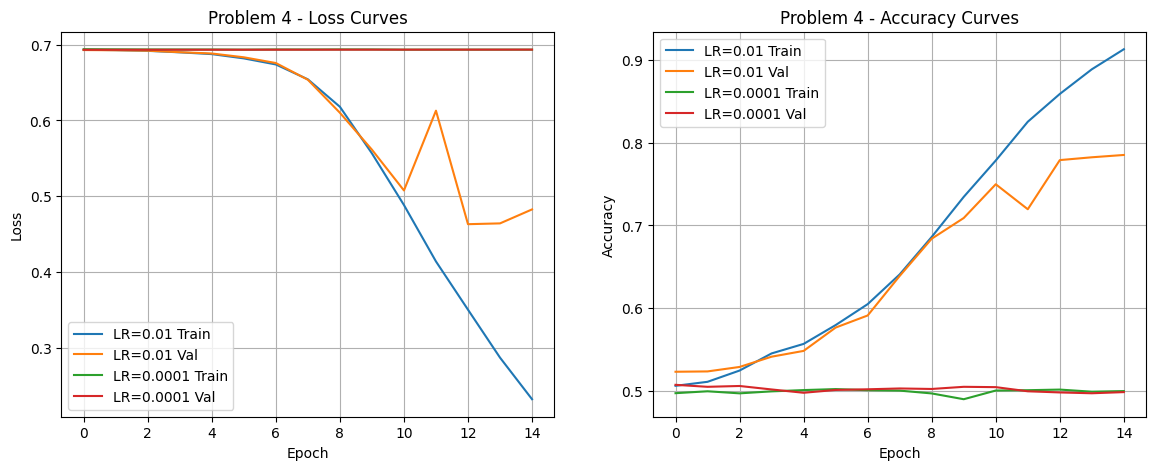


Higher LR converges faster but can be unstable. Lower LR is more stable but slower.


In [14]:
# LR = 0.01
opt_high = keras.optimizers.SGD(learning_rate=0.01)
model_high = keras.models.clone_model(model3)
model_high.compile(optimizer=opt_high, loss='binary_crossentropy', metrics=['accuracy'])
history_high = model_high.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=1)

test_acc_high = model_high.evaluate(X_test, y_test, verbose=0)[1]
print(f"LR=0.01 Test Accuracy: {test_acc_high:.4f}")

# LR = 0.0001
opt_low = keras.optimizers.SGD(learning_rate=0.0001)
model_low = keras.models.clone_model(model3)
model_low.compile(optimizer=opt_low, loss='binary_crossentropy', metrics=['accuracy'])
history_low = model_low.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=1)

test_acc_low = model_low.evaluate(X_test, y_test, verbose=0)[1]
print(f"LR=0.0001 Test Accuracy: {test_acc_low:.4f}")

# Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_high.history['loss'], label='LR=0.01 Train')
plt.plot(history_high.history['val_loss'], label='LR=0.01 Val')
plt.plot(history_low.history['loss'], label='LR=0.0001 Train')
plt.plot(history_low.history['val_loss'], label='LR=0.0001 Val')
plt.title('Problem 4 - Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_high.history['accuracy'], label='LR=0.01 Train')
plt.plot(history_high.history['val_accuracy'], label='LR=0.01 Val')
plt.plot(history_low.history['accuracy'], label='LR=0.0001 Train')
plt.plot(history_low.history['val_accuracy'], label='LR=0.0001 Val')
plt.title('Problem 4 - Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\nHigher LR converges faster but can be unstable. Lower LR is more stable but slower.")